# xmr_comparison function demo

In [1]:
# Import libraries
from process_improvement.charts.xmr_charts import xmr_comparison
from process_improvement.charts.utils import XmRChartConfig

from process_improvement.data_loader import list_example_files, load_example_data

%matplotlib inline

## Get data

In [2]:
# List example files
list_example_files()

['18650_battery_cells',
 '2170_battery_cell',
 'automated_manufacturing_part_lengths',
 'milikans_electron_charge_observations',
 'monthly_united_states_trade_deficits_2024',
 'OP200_weekly_first_pass_yield',
 'quarterly_sales_by_region',
 'shewharts_resistance_measurements',
 'software_verification_death_to_birth_rates',
 'software_verification_resistance_measurement',
 'wafer_assembly_part_placement']

In [3]:
# Create dataframe
df = load_example_data("wafer_assembly_part_placement")

df = df.drop(['Units'], axis=1)

df.head()

,Stage,Sample,X position
0,Baseline,1,0.681
1,Baseline,2,0.565
2,Baseline,3,0.577
3,Baseline,4,0.572
4,Baseline,5,0.565


In [4]:
# Get unique Stages
unique_stages = df['Stage'].unique().tolist()
unique_stages

['Baseline', 'Initial change', 'Secondary change']

## Create list of dataframes

In [5]:
# Create list of dataframes using unique stages
df_list = [g.copy().reset_index(drop=True) for _, g in df.groupby('Stage', sort=False)]

len(df_list)

3

## XmRChartConfiguration

In [13]:
# XmR chart configuration
config = XmRChartConfig(
    round_value=1,
    show_xticks=False,
    show_yticks=False,
    show_limit_values="none"
)

## XmR comparison of wafer placement stages

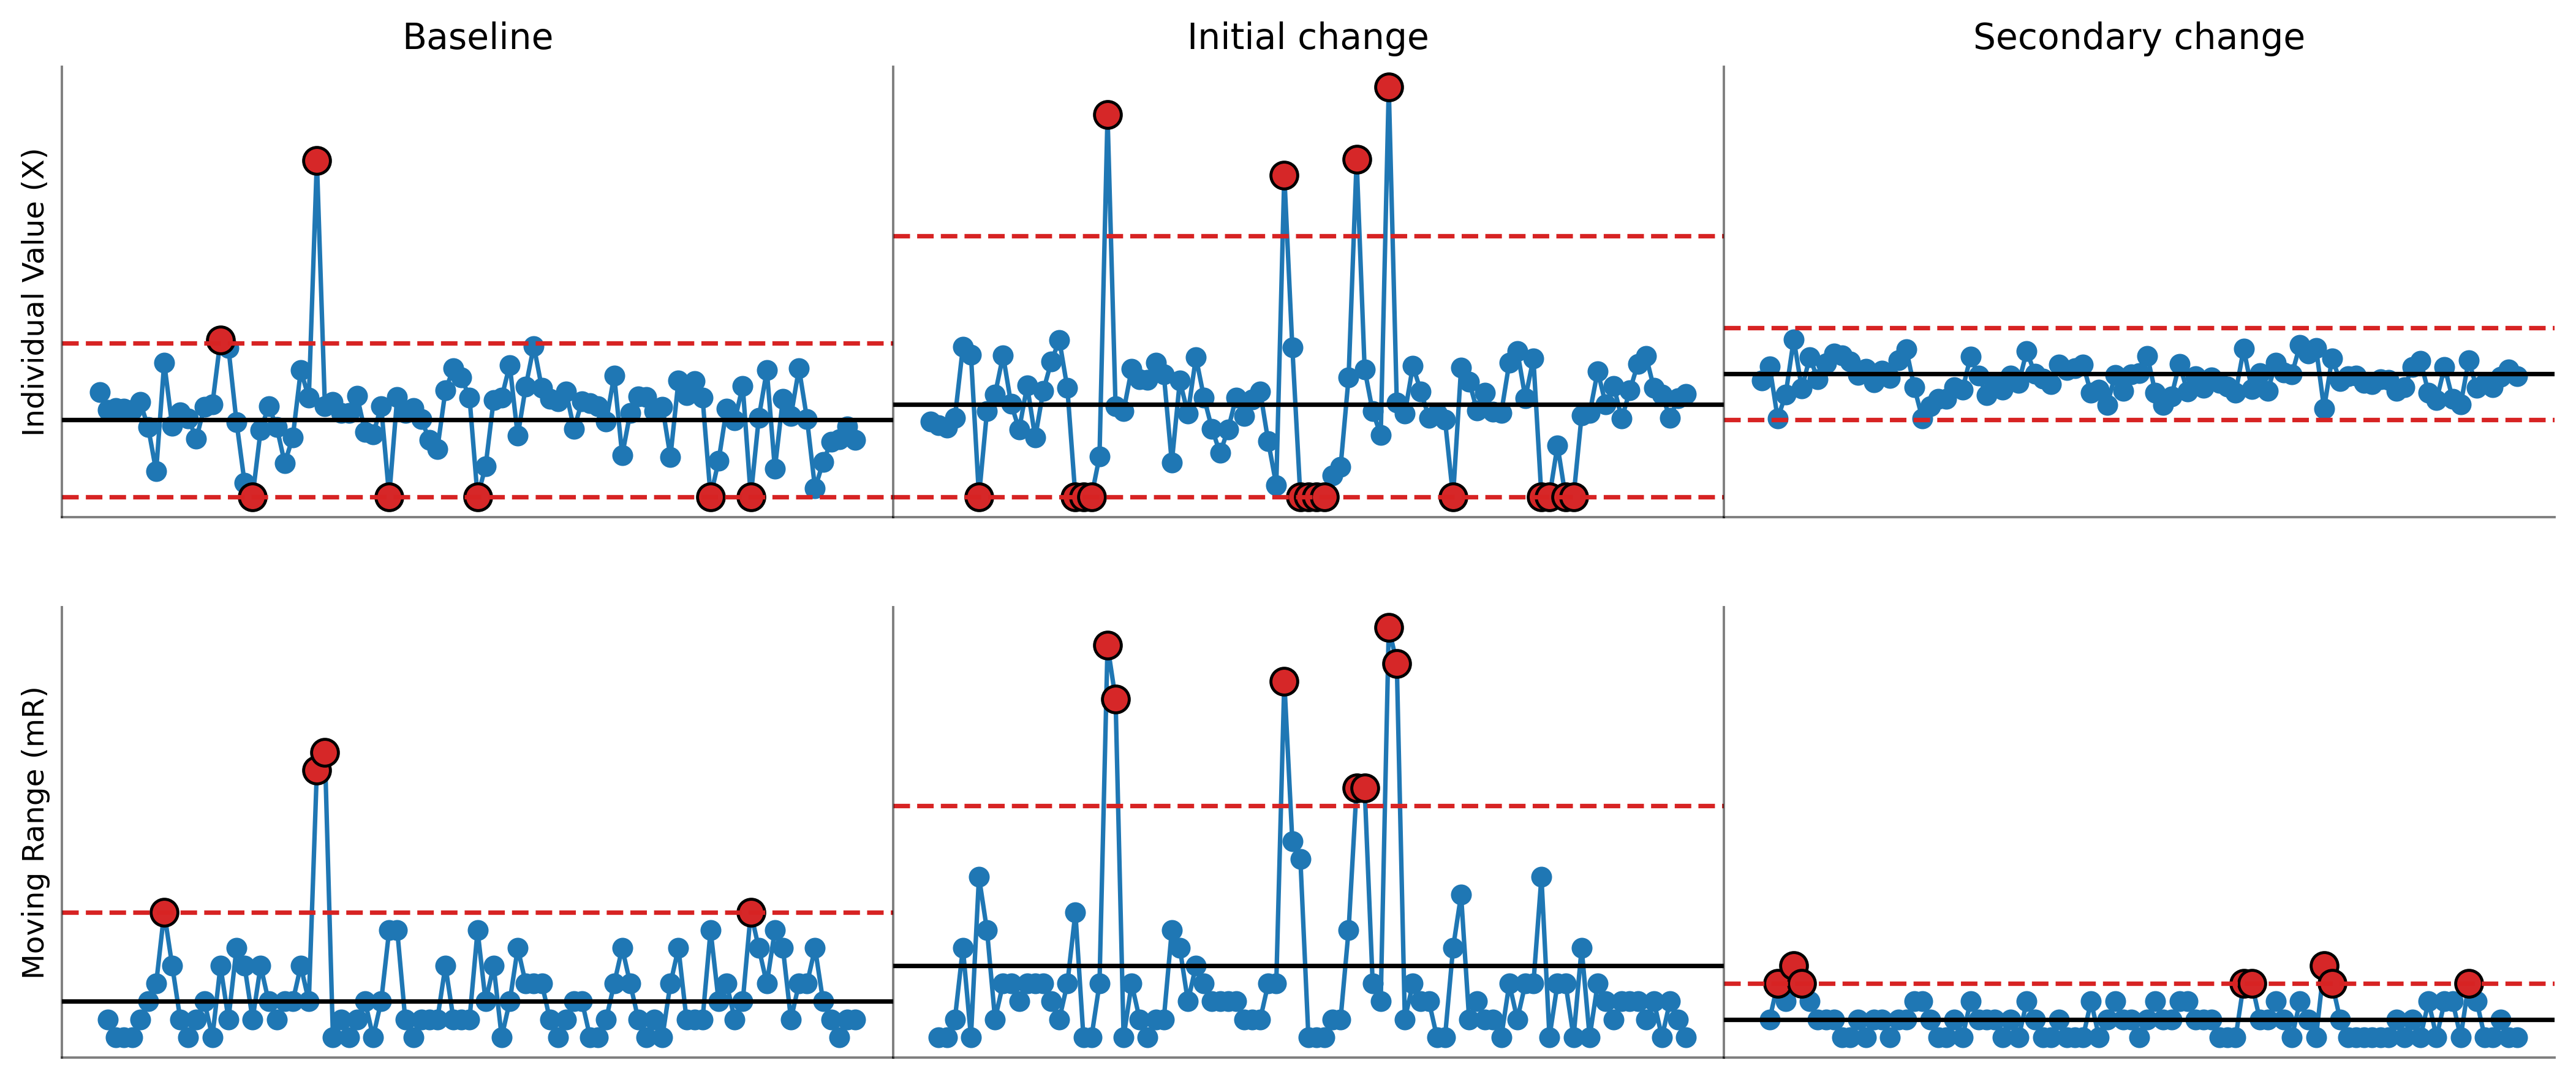

In [14]:
# Create XmR chart
results = xmr_comparison(
    df_list, 
    'X position', 
    'Sample',
    tickintervals=[9,12,15],
    subplot_titles = unique_stages,
    config=config
)

## Show process statistics

In [15]:
# Show statistics
results.stats_df

,Label,Chart,Process Stats,Values
0,Baseline,X chart,Mean,0.5
1,Baseline,X chart,UPL,1.0
2,Baseline,X chart,LPL,0.0
3,Baseline,X chart,PLR,1.1
4,Baseline,mR chart,Ave. mR,0.2
5,Baseline,mR chart,URL,0.7
6,Baseline,Overall,Characterization,Unpredictable
7,Initial change,X chart,Mean,0.6
8,Initial change,X chart,UPL,1.7
9,Initial change,X chart,LPL,0.0
